# F-16, 500 seconds: iADP and PID with a small actuator fault

At 20 seconds, the standard `DamageProfile` reduces the **entire stabilator command by 15%**, including its trim offset. Aerodynamic tables are unchanged; the actuator retains second-order dynamics and physical limits.

Four runs are compared: healthy/faulty aircraft × continued learning/parameters frozen after 20 s. Pre-event history is shared. The frozen controller continues receiving measurements and controlling the aircraft.

This example uses the longitudinal model at fixed speed and altitude; it does not reproduce the complete flight experiment in [Konatala et al. (2024)](https://doi.org/10.2514/6.2024-2402).

The second part compares iADP with a PID fitted **only on the healthy aircraft**. PID gains stay fixed after failure while its integrator remains active.

**Freezing parameters at the known failure time is a diagnostic control only.** It is not an operational adaptation strategy. A separate example, `example_iadp_fault_scenarios_f16.py`, tests continuous learning with failure schedules unknown to the controller; see `reports/iadp-f16-unknown-faults-validation.md`.

In [1]:
from pathlib import Path
import sys

# Works when Jupyter starts at the repository root or in this notebook's folder.
repo = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "tensoraerospace").is_dir())
sys.path.insert(0, str(repo))
from example.reinforcement_learning.incremental_adp.example_iadp_small_fault_f16 import (
    Experiment, run_experiment, save_results,
)
%matplotlib inline

## Configuration

`loss=0.15` means a 15% loss in the actuator-command gain. Try `0.0`, `0.10`, or `0.20` for comparison. The longitudinal model has a single collective stabilator channel: an event on `stab_left` affects this entire channel rather than modeling left-side asymmetry.

The agent uses measured pitch rate and the mean actual surface position over each step. Neither `loss` nor the event time is passed to it. The nominal model is used only for initialization.

In [2]:
cfg = Experiment(dt=0.02, duration=500.0, fault_time=20.0, loss=0.15, phase=0.0)
traces, report = run_experiment(cfg)
for name, metrics in report["metrics"].items():
    print(f"{name:18s} post-event RMSE: {metrics['after_fault']['rmse_deg_s']:.4f} °/s; "
          f"late window: {metrics['late']['rmse_deg_s']:.4f} °/s")
print("Fault-case RMSE reduction, %:", report["fault_rmse_reduction_percent"])
print("Matching pre-failure histories:", report["prefault_histories_match"])

healthy_adaptive   post-event RMSE: 0.2068 °/s; late window: 0.2215 °/s
healthy_frozen     post-event RMSE: 0.0908 °/s; late window: 0.0911 °/s
fault_adaptive     post-event RMSE: 0.1936 °/s; late window: 0.1665 °/s
fault_frozen       post-event RMSE: 1.2013 °/s; late window: 1.2008 °/s
Fault-case RMSE reduction, %: {'after_fault': 83.88633570460657, 'late': 86.1349637397942}
Matching pre-failure histories: True


CSV, JSON, PNG and SVG: /home/mr8bit/Projects/TensorAeroSpace/outputs/f16-iadp-500s/notebook-baseline


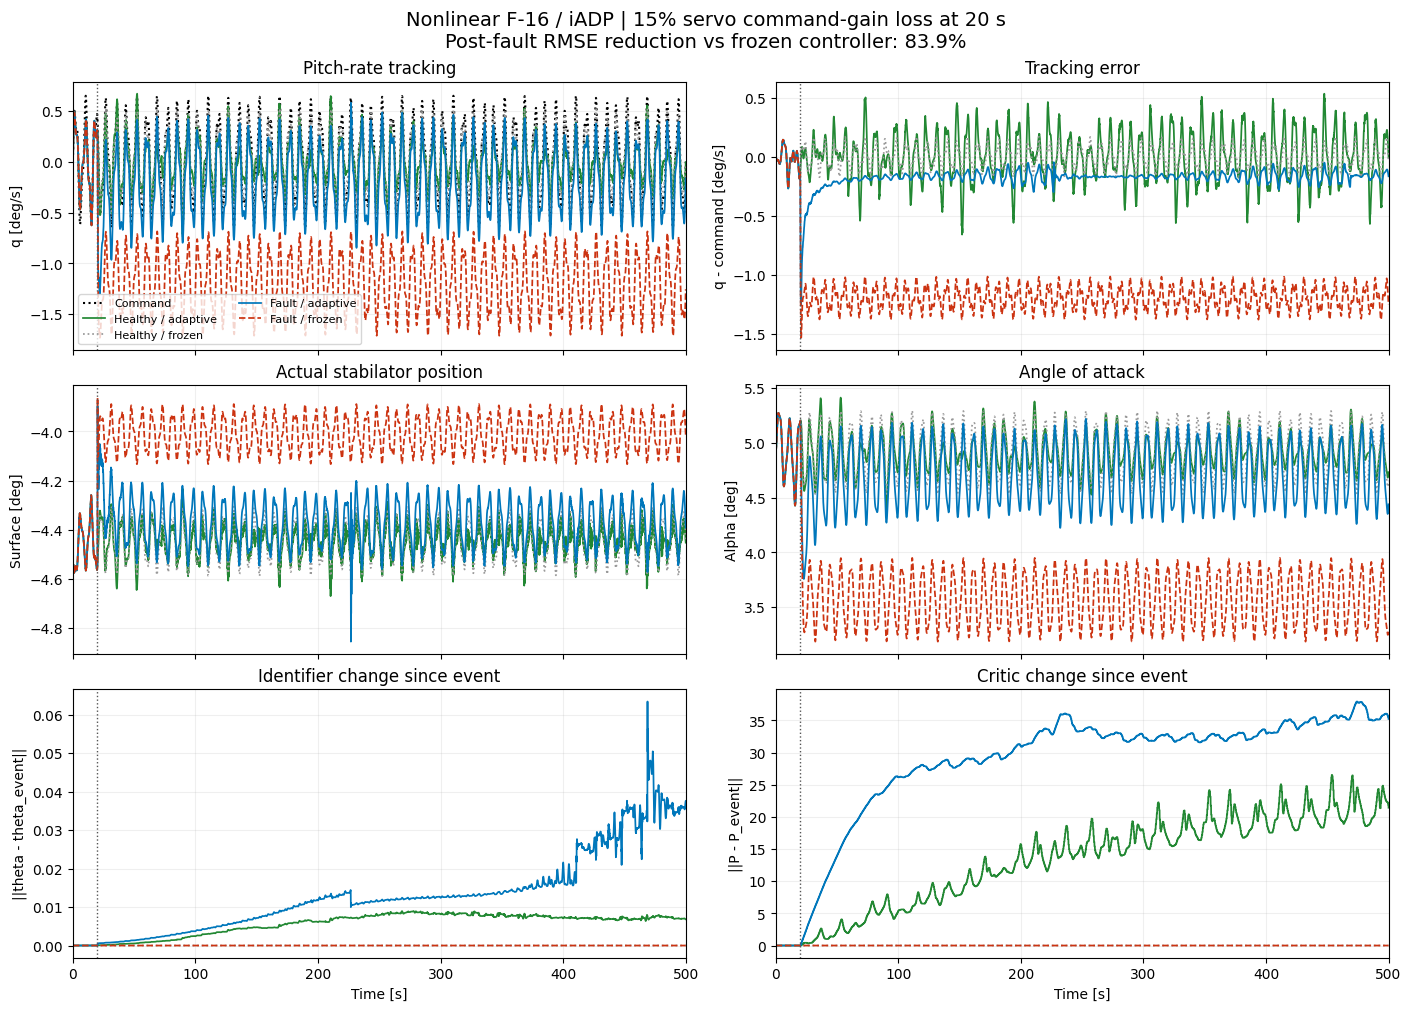

In [3]:
output = repo / "outputs" / "f16-iadp-500s" / "notebook-baseline"
fig = save_results(traces, report, output)
print(f"CSV, JSON, PNG and SVG: {output}")

## Reading the results

- Blue and red curves differ only in whether parameters can update after the event.
- The bottom row shows model and critic changes relative to their parameters at failure. This is not an estimate of mechanical damage percentage.
- Error does not vanish completely: compare both the full post-failure interval and its second half. All windows are recorded in JSON.
- Green and gray curves show the effect of continued learning on the healthy aircraft. In the original run, the frozen controller is more accurate there.

Success in this scenario does not prove convergence for every fault. Sensor noise, external gusts, and full spatial dynamics are absent. Initial control comes from nominal linearization and DARE rather than training from scratch.

## iADP vs PID fitted on the healthy F-16

PID was fitted offline on a separate 20-second fault-free trajectory with frequencies of 0.10 and 0.23 Hz. Evaluation uses 0.12 and 0.31 Hz. The objective minimizes the mean squared error in rad/s plus an actual-control penalty with the same `R` as iADP. It uses the project's PID with derivative on measurement and integrator anti-windup.

Both controllers start from the same trim state, share command limits, and receive identical references. The same failure occurs at 20 s. PID is not retuned; iADP continues learning. Aircraft states before failure may differ between algorithms because their controls differ; each algorithm is checked against its own healthy-aircraft run for pre-failure agreement.

Set `RETUNE_PID = True` to repeat fitting. By default, the previously fitted gains are used. This compares control performance, without equalizing offline training costs.

In [4]:
from example.reinforcement_learning.incremental_adp import example_iadp_vs_pid_f16 as comparison

RETUNE_PID = False
pid_gains = comparison.DEFAULT_PID_GAINS
pid_tuning = {"source": "healthy-only fitted gains", "fault_used": False}
if RETUNE_PID:
    pid_gains, pid_tuning = comparison.tune_pid()

paired_traces, paired_report = comparison.run_comparison(cfg, pid_gains)
paired_report["pid_tuning"] = pid_tuning
print("PID Kp, Ki, Kd:", pid_gains)
print("PID input: rad/s; output: command offset from trim in degrees.")
for algorithm in ("iadp", "pid"):
    m = paired_report["metrics"][f"{algorithm}_fault"]
    print(f"{algorithm.upper():4s}: pre-failure RMSE {m['before_fault']['rmse_deg_s']:.4f}; "
          f"20–25 s {m['initial_transient']['rmse_deg_s']:.4f}; "
          f"20–{cfg.duration:g} s {m['after_fault']['rmse_deg_s']:.4f}; "
          f"{(cfg.fault_time + cfg.duration)/2:g}–{cfg.duration:g} s {m['late']['rmse_deg_s']:.4f} °/s")

PID Kp, Ki, Kd: (-183.55882312255446, -499.9999999999999, -0.0013077268644681695)
PID input: rad/s; output: command offset from trim in degrees.
IADP: pre-failure RMSE 0.0968; 20–25 s 0.7675; 20–500 s 0.1936; 260–500 s 0.1665 °/s
PID : pre-failure RMSE 0.0095; 20–25 s 0.0647; 20–500 s 0.0128; 260–500 s 0.0110 °/s


iADP/PID comparison saved: /home/mr8bit/Projects/TensorAeroSpace/outputs/f16-iadp-500s/notebook-pid


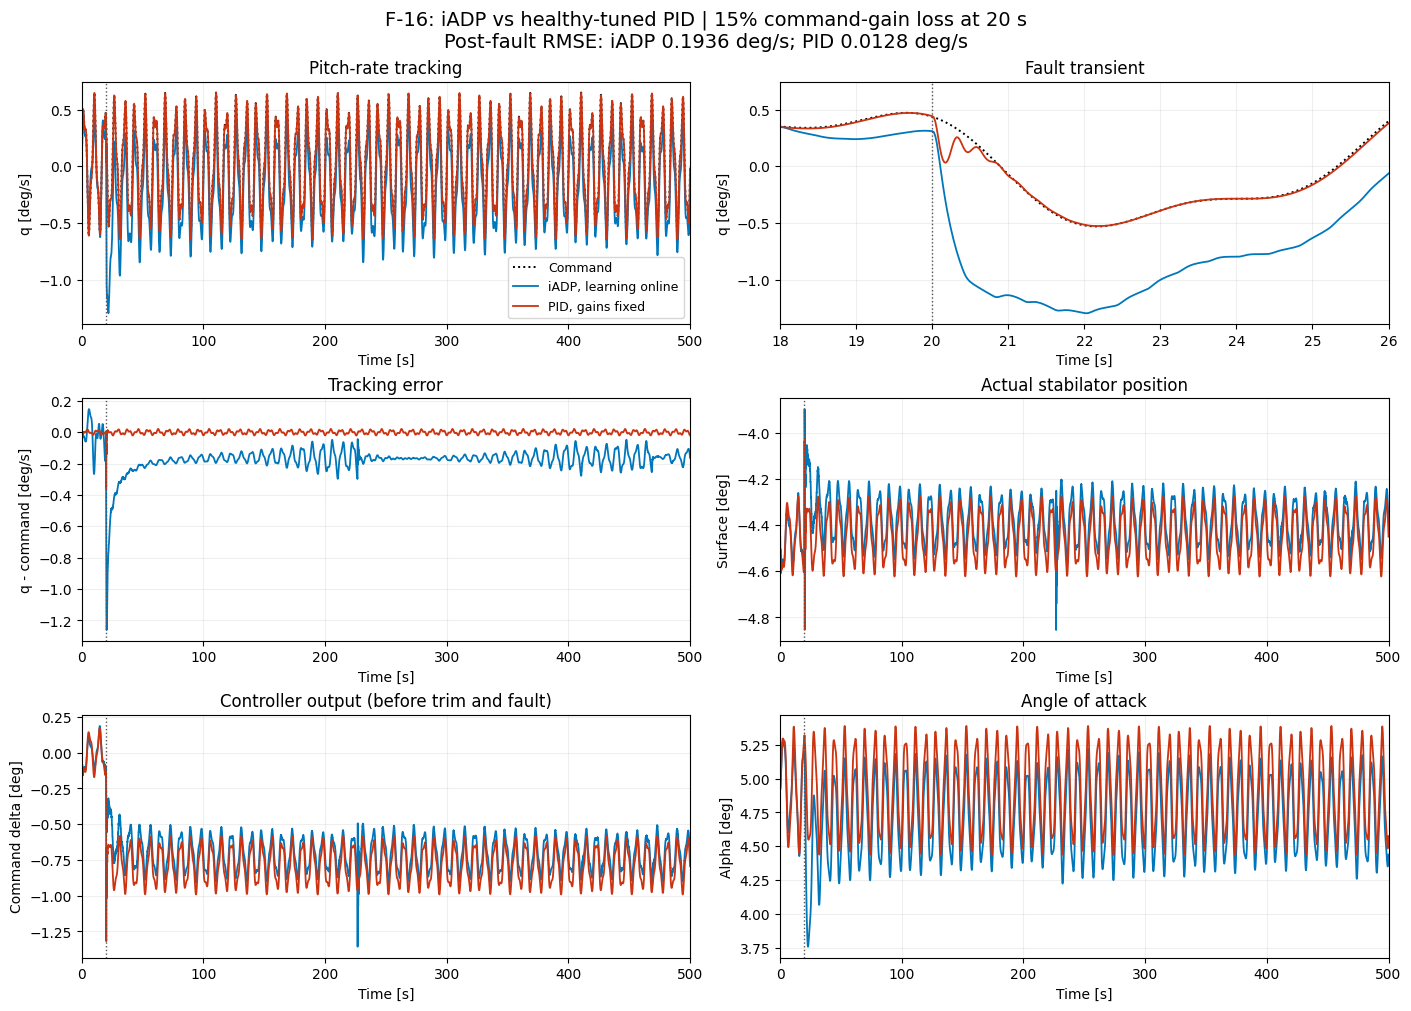

In [5]:
paired_output = repo / "outputs" / "f16-iadp-500s" / "notebook-pid"
paired_fig = comparison.save_results(paired_traces, paired_report, paired_output)
print(f"iADP/PID comparison saved: {paired_output}")

### Interpreting the original settings

Compare RMSE over the full post-failure interval and its second half. The end time comes from `cfg.duration`; all plots in this notebook cover 500 s.

An adaptation benefit relative to frozen original iADP does not imply superiority to PID. PID gains are fixed, but its integrator continues compensating for bias. `|Ki|` reached the nominal search boundary of 500; globally optimal PID tuning is not claimed.

## Improving iADP: parameters and an integral state

**Tuning the original iADP** and **iADP with an integral state** were tested separately. In the latter, the agent state is `[q, z]`, where `z[k+1] = z[k] + dt * (q_ref[k] - q[k])`, the reference is `[q_ref, 0]`, and `Q = diag(1, 30)`. This extends the input state and cost of the unchanged `IADPAgent`; it does not add an external PID correction.

The best parameters were selected by cost on the **healthy** F-16. Final settings: `R = 0.5 * R_original`, `gamma=0.99`, RLS forgetting factor `0.9995`, covariance `20000`, a 300-step window, critic updates every 10 steps, and blend `0.0001`. Critic learning starts once the window is full.

Set `REPEAT_IADP_SEARCH = True` to repeat the 27-candidate search on a healthy 60-second episode. Post-failure error is not used as the tuning objective. The *Fine-Tuning Controller Performance* discussion in the [original paper](https://doi.org/10.2514/6.2024-2402) addresses the absence of integral information in the base cost. The specific integral-state implementation here extends the experimental setup.

In [6]:
from example.reinforcement_learning.incremental_adp import example_iadp_tuned_f16 as improved

REPEAT_IADP_SEARCH = False
selected_tuning = improved.INTEGRAL_TUNING
search_report = None
if REPEAT_IADP_SEARCH:
    selected_tuning, search_report = improved.nominal_search()

improved_traces, improved_report = improved.run_comparison(cfg, selected_tuning)
improved_report["nominal_search"] = search_report
for name, m in improved_report["metrics"].items():
    print(f"{name:22s} post-failure RMSE: {m['after_fault']['rmse_deg_s']:.6f}; "
          f"late window: {m['late']['rmse_deg_s']:.6f} °/s; "
          f"recovery to the ±0.05 °/s band: {m['recovery_time_s']['0.05']} s")

iadp_original          post-failure RMSE: 0.193572; late window: 0.166486 °/s; recovery to the ±0.05 °/s band: None s
pid                    post-failure RMSE: 0.012796; late window: 0.010996 °/s; recovery to the ±0.05 °/s band: 0.740000000000002 s
iadp_rate_tuned        post-failure RMSE: 0.155181; late window: 0.157524 °/s; recovery to the ±0.05 °/s band: None s
iadp_integral          post-failure RMSE: 0.027711; late window: 0.035249 °/s; recovery to the ±0.05 °/s band: None s
iadp_integral_frozen   post-failure RMSE: 0.007337; late window: 0.003491 °/s; recovery to the ±0.05 °/s band: 0.6799999999999997 s


Tuned iADP: /home/mr8bit/Projects/TensorAeroSpace/outputs/f16-iadp-500s/notebook-tuned


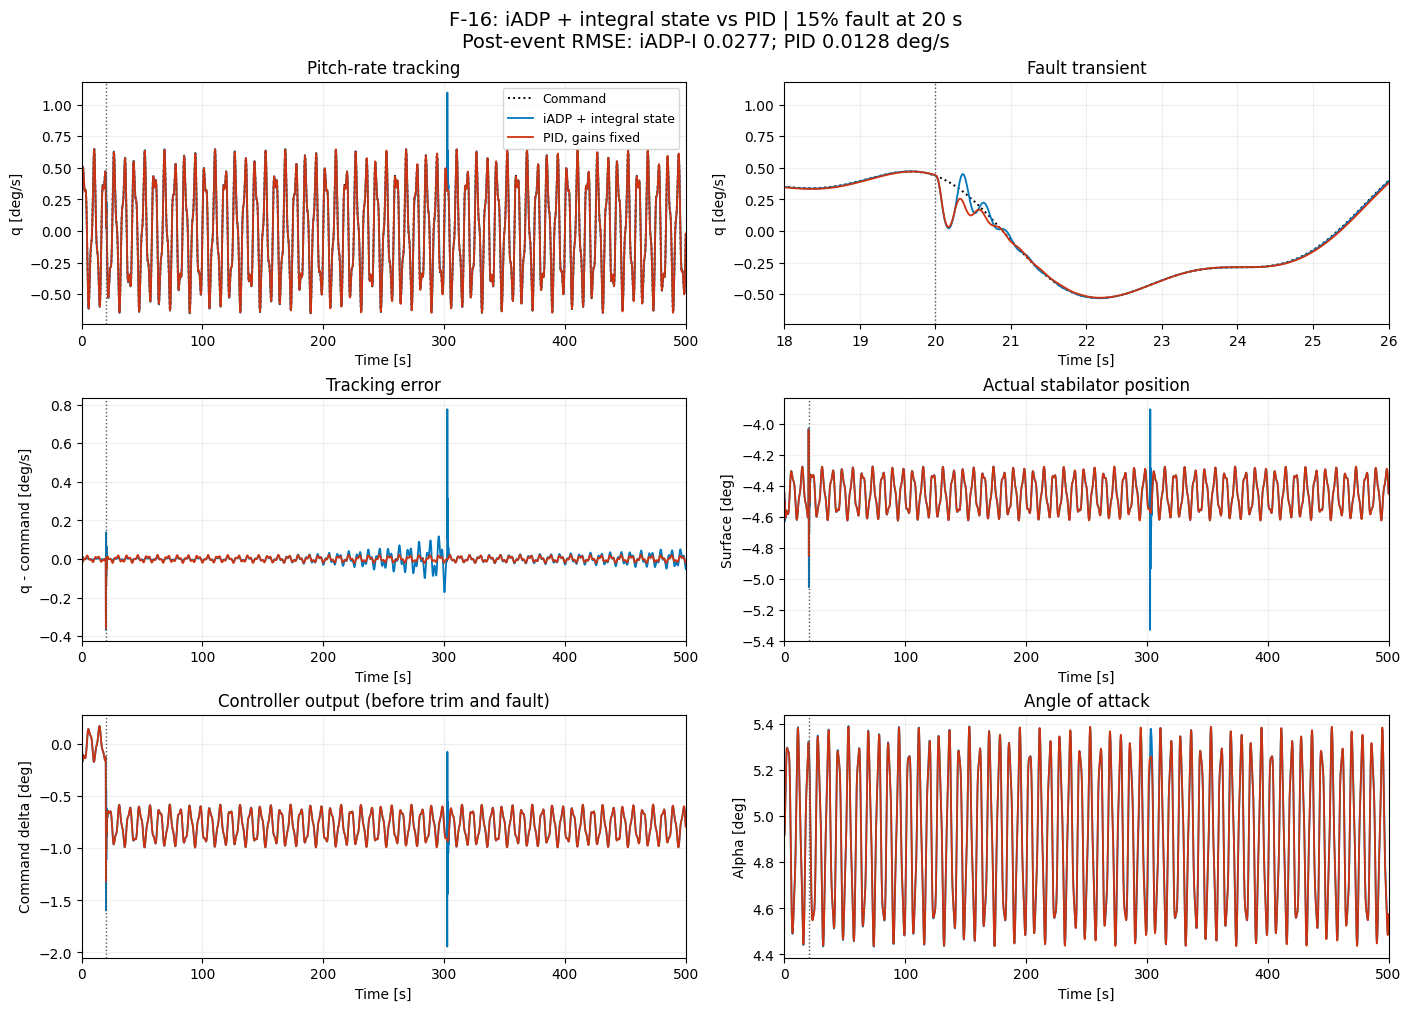

In [7]:
improved_output = repo / "outputs" / "f16-iadp-500s" / "notebook-tuned"
improved_figure = improved.save_results(improved_traces, improved_report, improved_output)
print(f"Tuned iADP: {improved_output}")

### Long-horizon evaluation

In the short 60 s episode, integral iADP achieved post-failure RMSE of 0.023084°/s versus 0.025177°/s for PID. **With continuous learning over 500 s, this advantage does not persist.** Error grows and late spikes appear. iADP frozen after 20 s retains integral feedback and stable accuracy. These settings were not retuned for this experiment.

The table below contains actual results from this run. The last 100 seconds are listed separately so that averaging does not hide deterioration. The longer run exposes a limitation of the learning configuration, but does not by itself prove an implementation bug.

Healthy-aircraft tests, critic/identifier parameter logs, and refined physics steps are provided by a separate reproducible example:

```bash
python -m example.reinforcement_learning.incremental_adp.example_iadp_long_horizon_f16
python -m example.reinforcement_learning.incremental_adp.example_iadp_long_horizon_f16 --substeps 2 --conditions fault --output outputs/f16-iadp-500s/substeps2
```

Full results and limitations: `reports/iadp-f16-500s-validation.md`.

In [8]:
import numpy as np
from IPython.display import Markdown, display
from example.reinforcement_learning.incremental_adp.example_iadp_long_horizon_f16 import window_metrics

rows = [f"| Controller | RMSE {cfg.fault_time:g}–{cfg.duration:g} s, °/s | RMSE over last 100 s, °/s |",
        "|---|---:|---:|"]
for name, trace in improved_traces.items():
    total = window_metrics(trace, cfg.fault_time, cfg.duration)
    tail = window_metrics(trace, max(cfg.fault_time, cfg.duration - 100), cfg.duration)
    rows.append(f"| {name} | {total['rmse_deg_s']:.6f} | {tail['rmse_deg_s']:.6f} |")
display(Markdown("\n".join(rows)))


| Controller | RMSE 20–500 s, °/s | RMSE over last 100 s, °/s |
|---|---:|---:|
| iadp_original | 0.193572 | 0.167892 |
| pid | 0.012796 | 0.011003 |
| iadp_rate_tuned | 0.155181 | 0.159755 |
| iadp_integral | 0.027711 | 0.021719 |
| iadp_integral_frozen | 0.007337 | 0.003484 |